In [1]:
import numpy as np
import pandas as pd, os, datetime

# Statistical analysis
from scipy import stats
import math
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
from tslearn.metrics import cdist_dtw

# plottinng
import matplotlib.pyplot as plt
from matplotlib import cm, colors
import folium

from IPython.display import HTML

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.10/lib/python3.11/site-packages/torch/cuda/__init__.py:58: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
df = pd.read_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv')

In [3]:
clust_df =  df.copy()

def smooth_curve(delta, window=3):
    return (
        pd.Series(delta)
        .rolling(window=window, center=True, min_periods=1)
        .mean()
        .to_numpy()
    )
piv_df = clust_df.pivot_table(columns='hour', index='DUID', values='median_diff')
piv_df = piv_df.apply(
    lambda row: smooth_curve(row.values),
    axis=1,
    result_type="expand"
)

In [4]:
arr = piv_df.to_numpy()
rows = piv_df.index.to_numpy()
hours = piv_df.columns.to_numpy()

In [5]:
# DOn't use DTW with PCA
full_mat = cdist_dtw(arr, arr)          # full (n, n) DTW distance matrix
distance_matrix = squareform(full_mat)  # condensed form for scipy.linkage

# distance_matrix = pdist(arr, metric='euclidean')   # condensed pairwise Euclidean distances
# full_mat = squareform(distance_matrix)             # full (n, n) distance matrix for silhouette

In [6]:
Z = linkage(distance_matrix, method='average')

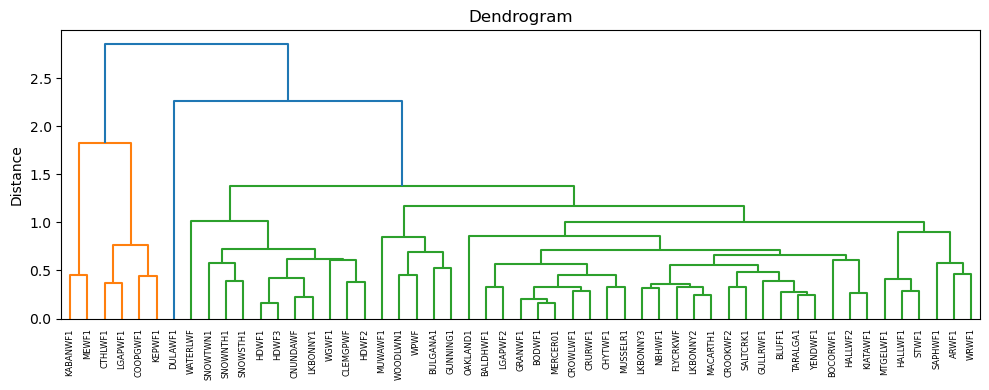

In [7]:
plt.figure(figsize=(10, 4))
dendrogram(Z, truncate_mode=None, labels=rows if len(rows) <= 200 else None,
           leaf_rotation=90, leaf_font_size=6)
plt.title("Dendrogram")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

Silhouette score (k=2, clusters=2): 0.588
Silhouette score (k=3, clusters=3): 0.481
Silhouette score (k=4, clusters=4): 0.421
Silhouette score (k=5, clusters=5): 0.346
Silhouette score (k=6, clusters=6): 0.333
Silhouette score (k=7, clusters=7): 0.290
Silhouette score (k=8, clusters=8): 0.272
Silhouette score (k=9, clusters=9): 0.251
Silhouette score (k=10, clusters=10): 0.211
Silhouette score (k=11, clusters=11): 0.193
Silhouette score (k=12, clusters=12): 0.196
Silhouette score (k=13, clusters=13): 0.202
Silhouette score (k=14, clusters=14): 0.230
Silhouette score (k=15, clusters=15): 0.238
Silhouette score (k=16, clusters=16): 0.245
Silhouette score (k=17, clusters=17): 0.248
Silhouette score (k=18, clusters=18): 0.239
Silhouette score (k=19, clusters=19): 0.235
Silhouette score (k=20, clusters=20): 0.220
Silhouette score (k=21, clusters=21): 0.223
Silhouette score (k=22, clusters=22): 0.223
Silhouette score (k=23, clusters=23): 0.253
Silhouette score (k=24, clusters=24): 0.242
Silh

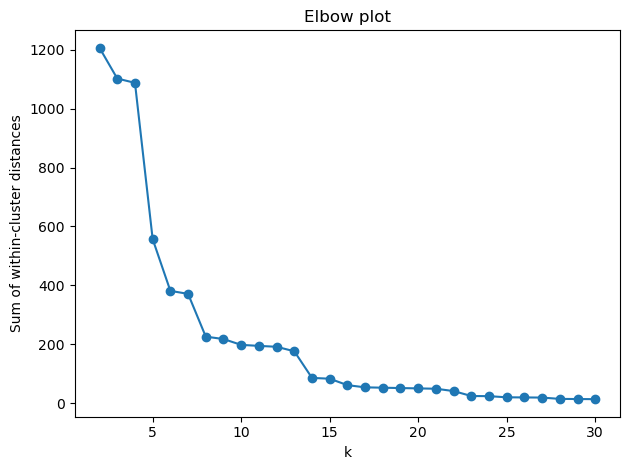

In [8]:
ks = []
wcss_values = []

for k in range(2, 31):
    labels = fcluster(Z, t=k, criterion='maxclust') - 1
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    n_samples = len(arr)

    if 1 < n_clusters < n_samples:
        try:
            sil = silhouette_score(full_mat, labels, metric='precomputed')
            print(f"Silhouette score (k={k}, clusters={n_clusters}): {sil:.3f}")

            # Elbow metric: sum of within-cluster distances
            wcss = 0.0
            for cl in unique_labels:
                idx = np.where(labels == cl)[0]
                if idx.size > 1:
                    sub = full_mat[np.ix_(idx, idx)]
                    wcss += sub.sum() / 2.0  # each pair counted twice
            ks.append(k)
            wcss_values.append(wcss)

        except Exception as e:
            print(f"Silhouette score (k={k}, clusters={n_clusters}): error computing silhouette: {e}")
    else:
        reason = "only one cluster" if n_clusters <= 1 else "clusters == number of samples"
        print(f"Silhouette score (k={k}): not defined ({reason}, clusters={n_clusters}, samples={n_samples})")

# Elbow plot
plt.figure()
plt.plot(ks, wcss_values, marker='o')
plt.xlabel("k")
plt.ylabel("Sum of within-cluster distances")
plt.title("Elbow plot")
plt.tight_layout()
plt.show()


In [9]:
k = 8
labels = fcluster(Z, t=k, criterion='maxclust') - 1
print(f"ACTUAL K SELECTED IS {k}")

ACTUAL K SELECTED IS 8


In [10]:
clusters_df = pd.DataFrame({'DUID': rows, 'cluster': labels}).set_index('DUID')
result = piv_df.copy()
result['cluster'] = clusters_df['cluster']  # aligns by index because rows == piv_df.index

In [11]:
duid_coords = pd.read_csv("/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/gen_info.csv")[['DUID','lat','lon']]

map_df = result[['cluster']].merge(duid_coords[['lat','lon',"DUID"]], on='DUID', how='left')

missing = map_df[['lat','lon']].isna().any(axis=1).sum()
if missing:
    print(f"Warning: {missing} DUIDs have missing coordinates and will be skipped on the map")

valid = map_df.dropna(subset=['lat','lon']).copy()

In [12]:
# Number of clusters
n_clusters_found = int(valid['cluster'].nunique())

# Colormap
cmap = cm.get_cmap('tab20', max(1, n_clusters_found))
norm = colors.Normalize(vmin=0, vmax=max(1, n_clusters_found - 1))

# Map center
center = [valid['lat'].mean(), valid['lon'].mean()]
m = folium.Map(location=center, zoom_start=6, tiles='CartoDB.Positron')

# Jitter scale (adjust if needed)
jitter_scale = 0.02  # ~0.02 degrees ~2km, tweak as needed

for duid, row in valid.iterrows():
    cl = int(row['cluster'])
    rgba = cmap(norm(cl))
    color_hex = colors.rgb2hex(rgba[:3])
    
    # Add jitter
    lat_jitter = row['lat'] + np.random.uniform(-jitter_scale, jitter_scale)
    lon_jitter = row['lon'] + np.random.uniform(-jitter_scale, jitter_scale)
    
    popup = folium.Popup(f"DUID: {row['DUID']}<br>cluster: {cl}", parse_html=True)
    folium.CircleMarker(
        location=[lat_jitter, lon_jitter],
        radius=5,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.8,
        popup=popup
    ).add_to(m)

display(HTML(m._repr_html_()))

/jobfs/164327606.gadi-pbs/ipykernel_977748/1518340794.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', max(1, n_clusters_found))


In [13]:
# import seaborn as sns

# sns.clustermap(
#     piv_df,
#     row_cluster=True,
#     col_cluster=False,
#     cmap='viridis',
#     figsize=(11, 11),
#     metric='euclidean',
#     method='average',
#     row_linkage=Z
# )
# plt.suptitle('Clustered IDs', y=1.02)
# plt.show()

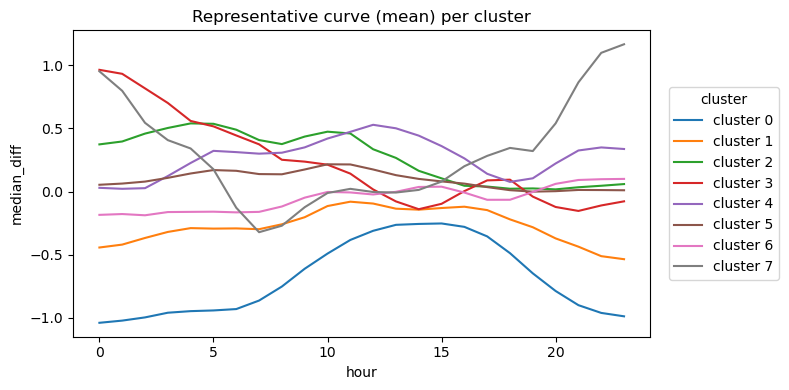

In [14]:
plt.figure(figsize=(8, 4))

hours = piv_df.columns.to_numpy()

for cl in sorted(result['cluster'].unique()):
    curves = result[result['cluster'] == cl][hours]
    mean_curve = curves.mean(axis=0)
    plt.plot(hours, mean_curve, label=f"cluster {cl}")

plt.xlabel("hour")
plt.ylabel("median_diff")
plt.title("Representative curve (mean) per cluster")

plt.legend(
    title="cluster",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()
plt.show()


In [15]:
result['cluster'].value_counts().sort_index()

cluster
0     2
1     4
2    10
3     1
4     5
5    24
6     6
7     1
Name: count, dtype: int64